# Quantum Phase Estimation

Problem: Given a unitary $U$ with a known eigenstate $|\psi\rangle$ such that $U|\psi\rangle=e^{2\pi i \varphi}|\psi\rangle$, estimate the phase $\varphi\in[0,1)$ up to $n$-bit precision ($0.\varphi_1\varphi_2...\varphi_n$).

This is done by creating an $n$-qubit counting register initialized to a uniform superposition in addition to an eigenstate register. From there, apply controlled-$U^{2^k}$ gates controlled on qubit $k$ in the counting register onto the eigenstate. This takes advantage of phase kickback since $U^{2^k}|\psi\rangle = e^{2\pi i 2^k \varphi}|\psi\rangle$ resulting in relative phase $e^{2\pi i 2^k \varphi}$ on qubit $k$. Thus, this results in $\varphi$ being encoded across all the qubits in the Fourier basis, such that applying the inverse QFT thus converts this phase pattern back into a binary number which is approximately $\varphi$ up to $n$-bit precision.

Phase estimation is the essential subroutine in Shor's algorithm as it is the mechanism for period-finding with modular exponentiation functions.

In this notebook I tested the quantum phase estimation with single eigenstates, which return a single phase, although only with high probability rather than certainty if $\varphi$ is not actually represented in $n$ bits, but also tested with a superposition of eigenstates, in which case one of the eigenphases is measured each time with probability according to the eigenstate's weight in the superposition. 

In [31]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.circuit import Gate
from qiskit.circuit.library import QFTGate, PhaseGate
from qiskit.visualization import plot_histogram
from IPython.display import display
import numpy as np

In [32]:
def make_squared_unitaries(unitary, k): #build controlled U^2^i gates
    assert isinstance(unitary, Gate)
    unitaries = []
    for i in range(0, k):
        unitary_2k = unitary.power(2**i)
        c_unitary = unitary_2k.control(1)
        unitaries.append(c_unitary)
    return unitaries

In [33]:
def make_qpe_circuit(unitary, eigenstate, n):
    assert isinstance(unitary, Gate)
    assert callable(eigenstate)
    eigenstate_size = unitary.num_qubits
    unitaries = make_squared_unitaries(unitary, n)
    qc = QuantumCircuit(n + eigenstate_size, n)
    eigenstate_qubits = list(range(n, n+eigenstate_size))
    eigenstate(qc, eigenstate_qubits)
    for i in range(n):
        qc.h(i)
    for i in range(n):
        qc.append(unitaries[i], [i] + eigenstate_qubits)
    qc.append(QFTGate(n).inverse(), range(n))
    qc.measure(range(n), range(n))
    return qc

In [34]:
def find_peaks(counts, n, min_count = 0): #finds local maxima, allowing for multiple eigenphases
    by_int = {}
    for outcome, count in counts.items():
        idx = int(outcome,2)
        by_int[idx] = (outcome, count)
    peaks = []
    for idx, (outcome,count) in by_int.items():
        if count < min_count:
            continue
        left = by_int.get(idx-1, (None, 0))[1]
        right = by_int.get(idx+1, (None, 0))[1]
        if count > left and count > right:
            phi = sum(int(outcome[i]) * 2**(-(i+1)) for i in range(n))
            peaks.append((outcome, count, phi))
    peaks.sort(key=lambda x: -x[1])
    return peaks

In [35]:
def get_phase(outcome, n):
    phi = sum(int(outcome[i]) * 2**(-(i+1)) for i in range(n))
    eigenvalue = np.exp(2 * np.pi * 1j * phi)
    print(f'Phase: {phi} --> Eigenvalue: {eigenvalue}')

In [36]:
def run_qpe(unitary, eigenstate, n, shots = 1000, min_count = 20):
    qc = make_qpe_circuit(unitary, eigenstate, n)
    print(f'Quantum Phase Estimation of {unitary.label} for {eigenstate.__name__} to {n}-bit precision')
    display(qc.draw('mpl'))

    sampler = StatevectorSampler(default_shots=shots)
    result = sampler.run([qc]).result()
    counts = result[0].data.c.get_counts()
    display(plot_histogram(counts))
    peaks = find_peaks(counts, n, min_count)
    if len(peaks) > 1:
        print("Multiple peaks - Superposition of eigenstates, multiple eigenvalues ")
    else:
        print("Single peak - Single eigenstate, single eigenvalue")
    for outcome, count, phi in peaks:
        get_phase(outcome, n)

In [37]:
U = PhaseGate(2 * np.pi / 3, label='P(2π/3)')
n = 5
def eigenstate_0(qc, qubits):
    pass
def eigenstate_1(qc, qubits):
    qc.x(qubits[0])
def eigenstate_superposition(qc, qubits):
    qc.h(qubits[0])

Quantum Phase Estimation of P(2π/3) for eigenstate_0 to 5-bit precision


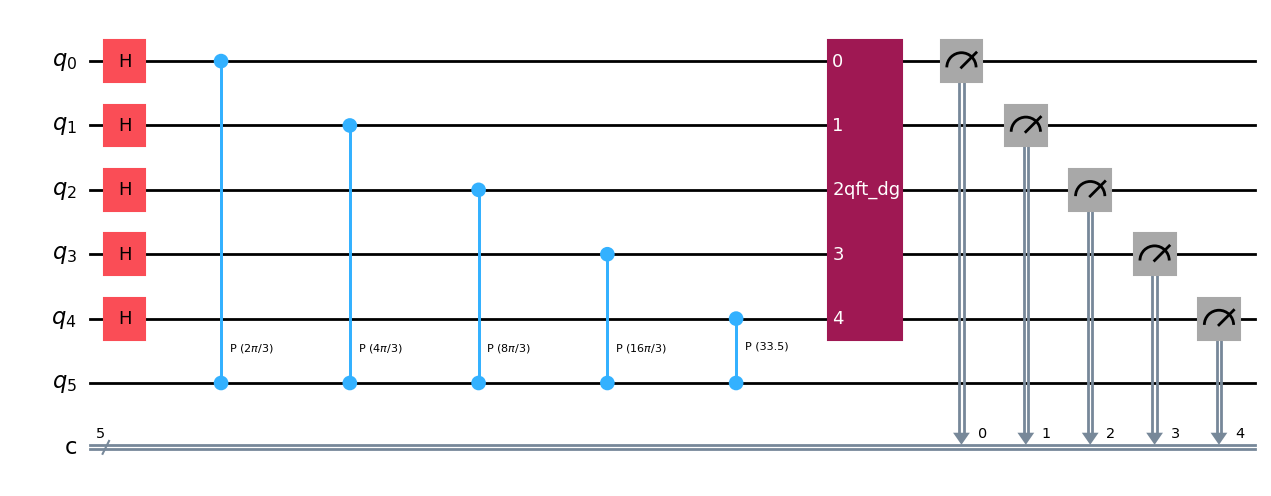

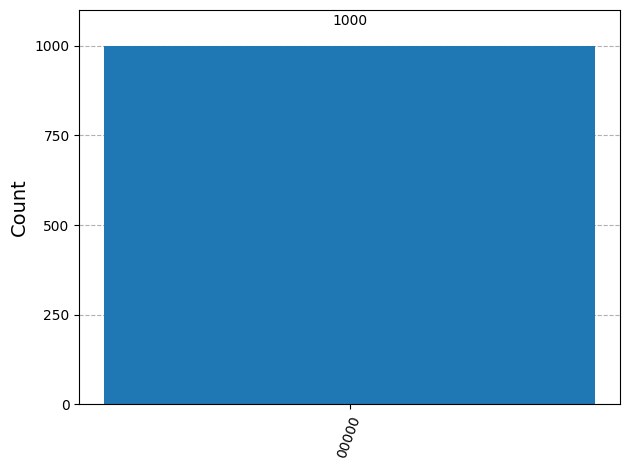

Single peak - Single eigenstate, single eigenvalue
Phase: 0.0 --> Eigenvalue: (1+0j)


In [38]:
#0 eigenstate - expected phase - 0
run_qpe(U, eigenstate_0, n)

Quantum Phase Estimation of P(2π/3) for eigenstate_1 to 5-bit precision


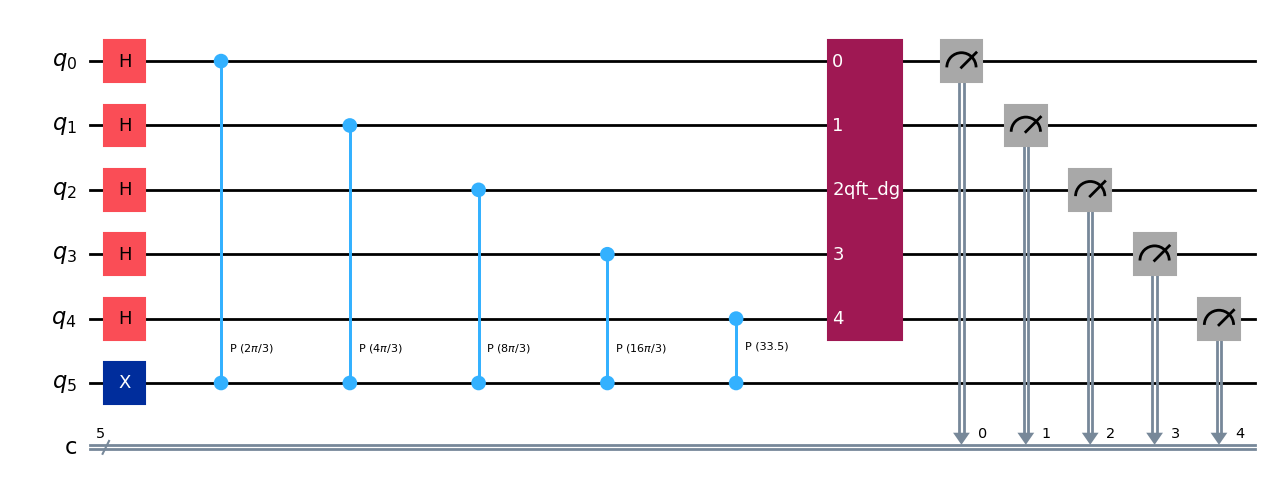

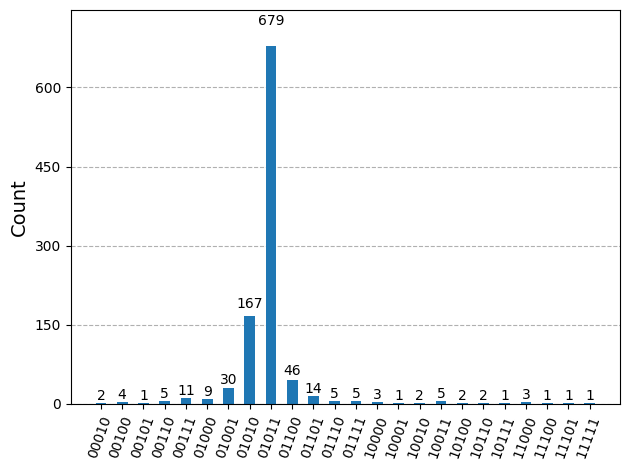

Single peak - Single eigenstate, single eigenvalue
Phase: 0.34375 --> Eigenvalue: (-0.555570233019602+0.8314696123025453j)


In [39]:
#1 eigenstate - expected phase 1/3 approximated to 5-bits
run_qpe(U, eigenstate_1, n)

Quantum Phase Estimation of P(2π/3) for eigenstate_superposition to 5-bit precision


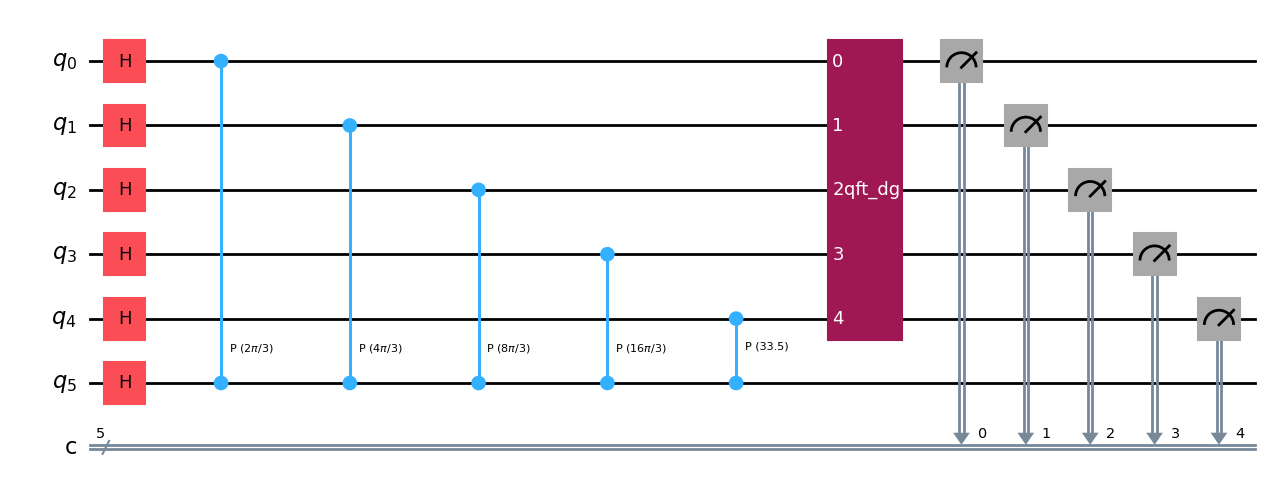

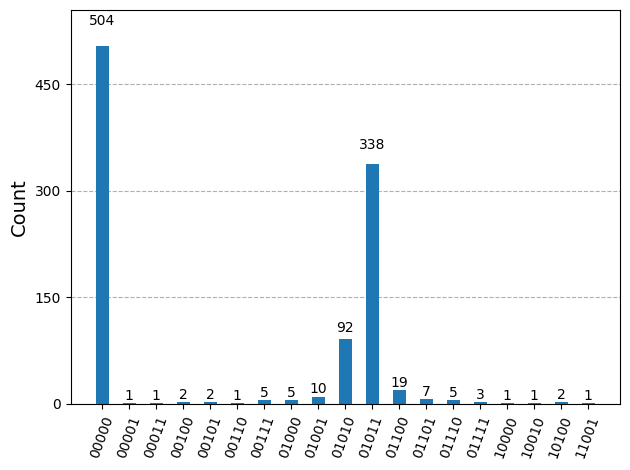

Multiple peaks - Superposition of eigenstates, multiple eigenvalues 
Phase: 0.0 --> Eigenvalue: (1+0j)
Phase: 0.34375 --> Eigenvalue: (-0.555570233019602+0.8314696123025453j)


In [40]:
#superposition of eigenstates 0 and 1 - expected phases 0 and 1/3 approximated to 5 bits
run_qpe(U, eigenstate_superposition, n)